# HR 예측 AI모델 개발

## 개요
- 탑승자의 심박수(Heart Rate: HR)를 예측하는 AI 모델 개발

## 분석 배경 
- 심박수는 차량 주행 과정에서 탑승자의 상태를 파악할 수 있는 대표적인 지표 중 하나
- 특정 주행 상태에서 탑승자의 심박수가 과도하게 높다면 이는 탑승자에게 불안한 주행일 가능성을 의미
- 반대로 특정 주행 상태에서 탑승자의 심박수가 너무 낮다면 이를 통해 탑승자가 졸음운전 등의 이유로 운전이 불가능한 상태임을 유추할 수 있음
- 따라서 차량 주행 상태와 심박수의 관계를 명확하게 밝혀낼 수 있다면, 탑승자에게 적정 심박수를 유지하게 하는 주행 알고리즘을 개발하거나, 탑승자의 상태를 모니터링하는 시스템을 개발할 수 있음

## 평가 지표
- MAE : Mean Absolute Error
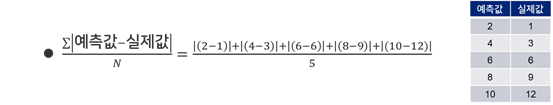

## 데이터 셋 정보

### [Data Files]
- train.csv: 학습용 데이터 (Features, Target) - 100,000건 
- test.csv:  예측용 데이터 (Features) - 49,980건

### [Feature]
- ID : 샘플 별 고유 ID
- CT : 조향장치 칼럼 토크
- MS : 조향장치 모터 회전속도
- MC : 조향장치 모터 전류
- B_Depth : 브레이크압
- LAT_ACCEL : 횡가속도
- LONG_ACCEL : 종가속도
- E_Status : 엔진상태
    - 0 : Engine Stop, 1 : Part Load, 2 : Pull , 3: Fuel Cut off, 4 : Start, 5 : Idle Speed
- A_Depth : 엑셀 페달 깊이
- F_Economy : 하이브리드 차량 연비
- Inhibit : 기어봉 위치
    - P : Parking, R : Reverse, N : Neutral, D : Drive
- Elevation : 고도

### [Target]
- HR : 심박수

## 분석 단계 
- **[step1] 라이브러리 및 데이터 불러오기** 
 - (1) 라이브러리 불러오기
 - (2) 데이터 불러오기 
 - (3) 데이터 확인 
 - (4) 데이터 타입 변환 (필요시)
- **[step2] 탐색적 데이터 분석 (EDA)**
 - (1) 기술적 통계분석
 - (2) 변수별 분포 시각화  
- **[step3] 데이터 전처리**
 - (1) 중복값 처리 **(Train셋만)**
 - (2) 불필요한 Feature삭제 (ID 등)
 - (3) 결측치 처리 
 - (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
 - (5) Feature, Target 설정
 - (6) 원핫 인코딩 **(feature-질적변수만)**
 - (7) 스케일링 **(feature-양적변수만)**
- **[step4] 모델 설계** 
 - (1) 훈련 및 검증 데이터 분할
 - (2) 평가지표 확인
 - (3) 알고리즘별 학습, 예측, 평가 
 - (4) 하이퍼파라미터 튜닝
- **[step5] 모델 선택 및 적용**
 - (1) test data의 예측값 생성
 - (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)
- **[step6] 결과 파일 생성** 
 - (1) 예시 파일 불러오기 
 - (2) test data의 예측 결과 저장 
 - (3) 제출할 csv파일 생성

#### 지금부터 분석과 예측을 시작합니다.  학습한 내용을 바탕으로 실력을 발휘해 보세요!

## [Step1] 불러오기
### (1) 라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# regression models
from sklearn.linear_model import <blank> # 선형회귀
from sklearn.tree import DecisionTreeRegressor # 회귀트리

from sklearn.ensemble import RandomForestRegressor # 랜덤 포레스트
from sklearn.ensemble import ExtraTreesRegressor # 엑스트라 트리

from xgboost import XGBRegressor # XGB
from lightgbm import LGBMRegressor # LGBM

In [ ]:
from sklearn.model_selection import <blank>  #학습셋과 검증셋 분리
from sklearn.metrics import <blank>  #MAE
from sklearn.model_selection import GridSearchCV

### (2) 데이터 불러오기

**train data**

In [ ]:
#train set load
train = pd.read_csv('./data/train.csv')
train

**test data**

In [ ]:
#test set load
test = pd.read_csv('./data/test.csv')
test

### (3) 데이터 확인 
 - df.info()

In [ ]:
# train


In [ ]:
# test
test.info()

- 모든 변수의 Non-Null Count 값을 통해 train과 test data에 결측치가 없음을 확인

## [Step2] 탐색적 데이터 분석 (EDA)

### (1) 기술통계분석
- describe()를 이용한 통계치 확인

In [ ]:
# train


In [ ]:
# test
test.describe()

### (2) 변수별 분포 시각화 

#### 1) 변수들간 상관관계를 보여주는 pairplot

In [ ]:
plt.figure(figsize = (15,15))


plt.show()

- E_Status / Inhibit : 범주형 변수
- Inhibit : 문자열값이라 plot에서 제외

#### 2) 연속형(양적) 변수의 분포를 보여주는 histplot 

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20,10))

sns.histplot(data =train, x = 'CT', ax=axes[0][0])
sns.histplot(data =train, x = 'MS', ax=axes[0][1])
sns.histplot(data = train, x='MC', ax=axes[0][2])
sns.histplot(data = train, x='B_Depth', ax=axes[0][3])
sns.histplot(data = train, x='LAT_ACCEL', ax=axes[0][4])
sns.histplot(data = train, x='LONG_ACCEL', ax=axes[1][0])
sns.histplot(data = train, x='A_Depth', ax=axes[1][1])
sns.histplot(data = train, x='F_Economy', ax=axes[1][2])
sns.histplot(data = train, x='Elevation', ax=axes[1][3])
sns.histplot(data = train, x='HR', ax=axes[1][4])

plt.show()

- ['CT', 'MS', 'MC', 'LAT_ACCEL', 'LONG_ACCEL', 'Elevation']
    - 분포가 중앙으로 몰려있는 형태
    - 평균을 0으로, 표준편차를 1로 하는 StandardScaler 적용
- ['B_Depth', 'A_Depth', 'F_Economy']
    - 분포가 한 쪽으로 치우친 형태
    - 최솟값을 0 최댓값을 1로 변환하는 MinMaxScaler 적용

In [ ]:
# 시각화할 컬럼 리스트
columns = ['CT', 'MS', 'MC', 'B_Depth', 'LAT_ACCEL', 
           'LONG_ACCEL', 'A_Depth', 'F_Economy', 'Elevation', 'HR']

In [ ]:
# 서브플롯 생성 (2행 5열)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  

- for문을 이용한 차트작성

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  

#반복문으로 코드 수정
for col_, ax_ in zip(columns, axes.flatten()):
    sns.histplot(data=train, x=col_, ax=ax_)

plt.show()

- target값 로그변환 필요성 검토



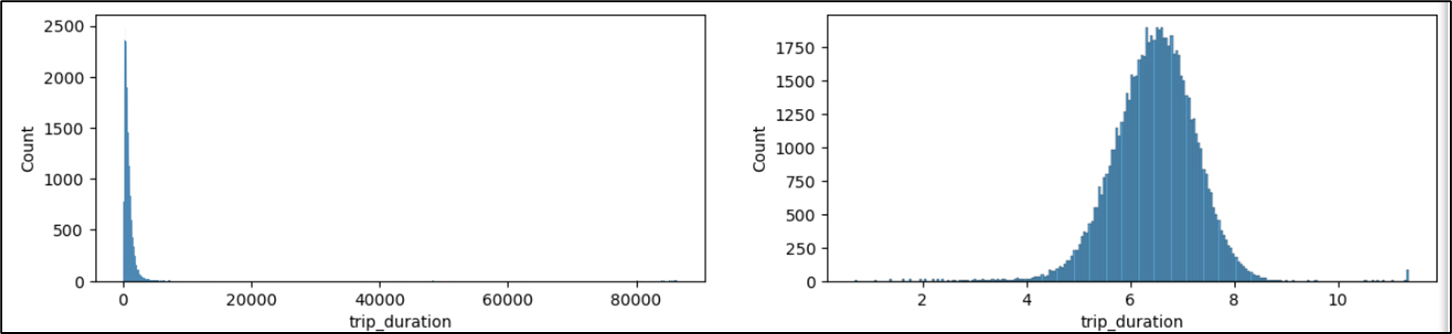

In [ ]:
# target값의 원데이터와 로그변환데이터의 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(x = train['HR'], ax=axes[0])
sns.histplot(x = <blank>(train['HR']), ax=axes[1])  # 로그변환값

plt.show()

- 로그 변환후의 분포 변화가 거의 없음. 따라서 변환하지 않음
- (실제로 해보면, 로그 변환 여부에 따른 예측 성능 차이가 거의 없음)

#### 3) 범주형(질적) 변수의 빈도를 보여주는 countplot

In [ ]:
#figsize=(15,5)

sns.countplot(x = train['E_Status'], ax=axes[0])
#'Inhibit'도  추가

plt.show()


## [step3] 데이터 전처리

### (1) 중복값 처리  **(Train셋만)**

In [ ]:
# train 셋의 중복값 확인


### (2) 불필요한 Feature 삭제

In [ ]:
# train 셋의 ID컬럼 삭제


In [ ]:
# test 셋의 ID컬럼 삭제


### (3) 결측치 처리

- df.info()를 통해 train과 test 데이터에 결측치가 없음을 이미 확인 했음
- 추가적으로 아래 방법으로도 확인 가능

In [ ]:
# train셋 확인
train.isna().sum()

In [ ]:
# test셋 확인
test.isna().sum()

### (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
- 회귀모델이므로 target값의 아웃라이어를 먼저 체크

In [ ]:
# boxplotting을 통해 target값의 outlier 존재여부 확인
sns.boxplot(y=<blank>, data=train)   
plt.show()

- 아웃라이어 제거 방법
    - 1) 사분위수 범위(IQR = Q3-Q1)을 계산
    - 2) **Q1-1.5IQR**과 **Q3+1.5IQR**을 각각 max와 min으로 설정
    - 3) [min, max]를 벗어나는 데이터는 아웃라이어로 간주하여 제거

In [ ]:
# 1) 사분위수 범위(IQR = Q3-Q1)을 계산 
Q1 = train['HR'].<blank>(0.25)
Q3 = train['HR'].quantile(<blank>)
IQR = <blank> - <blank>
print(IQR)

In [ ]:
#2) Q1-1.5IQR과 Q3+1.5IQR을 각각 max와 min으로 설정 
MIN = <blank>
MAX = <blank>

In [ ]:
# 3) [min, max]를 벗어나는 데이터는 극치로 간주하여 제거 
#실제로는 train을 사용(아웃라이어 제거 안함)
train2=train[(<blank>) & (<blank>)]
train2

- 총 5,061개의 극단치가 제거되어 train data의 갯수가 94,939개가 됨

### (5) Feature, Target 설정
- train 셋: Feature / Target 으로 분리
- test 셋: Feature만 설정

In [ ]:
# train set - features 설정
Xtrain=<blank>

In [ ]:
# train set -- target 설정
ytrain=<blank>

In [ ]:
# test set - features
Xtest=<blank>

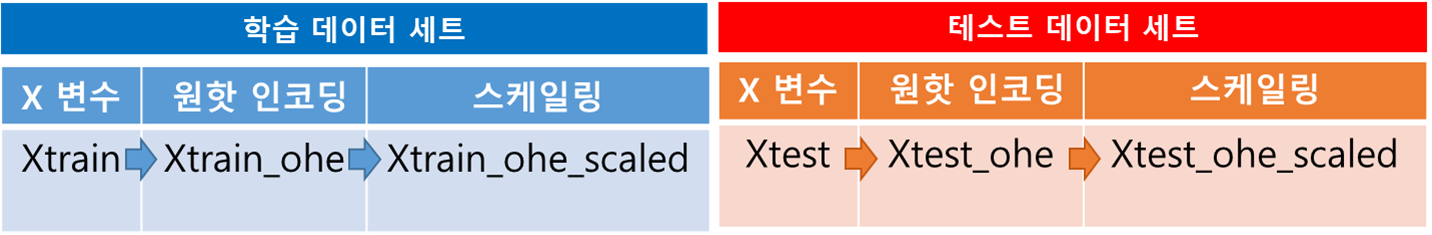

### (6) 원핫 인코딩 **(feature-질적변수만)**
- get_dummies(df, columns=[해당 column명])
- 카테고리 변수인 Inhibit과 E_Status에 대해서 수행

In [ ]:
Xtrain_ohe =  pd.get_dummies(Xtrain, <blank> = ['Inhibit','E_Status']) 
Xtest_ohe = <blank>

In [ ]:
Xtrain_ohe

In [ ]:
Xtest_ohe

- 원핫 인코딩 이후 총 feature가 증가함

### (7) 스케일링 **(feature-양적변수만)**
- 스케일링을 통해 변수들의 데이터 분포나 범위를 조정

**[주의] 스케일링 시 주의사항**
- fit (스케일링을 위한 계산 수행): train data
- transform(적용): train data & test data 

In [ ]:
# class import
from sklearn.preprocessing import <blank>, <blank>

#object 선언
minmax_scaler = <blank>
standard_scaler = <blank>

In [ ]:
#scaling된 xtrain을 별도 생성
Xtrain_ohe_scaled = <blank>

In [ ]:
# MinMaxScaling
Xtrain_ohe_scaled[['B_Depth', 'A_Depth', 'F_Economy']] = <blank>

# StandardScaling
Xtrain_ohe_scaled[['CT', 'MS', 'MC', 'LAT_ACCEL','LONG_ACCEL', 'Elevation']] = <blank>

In [ ]:
# test 셋
Xtest_ohe_scaled = <blank>

# MinMaxScaling

# StandardScaling



## [step4] 모델 설계 
- 모델의 선택 및 학습, 예측, 평가 분석 모델 설계
 - 다양한 모델의 성능비교 실시 
    - 선형 모델 - LinearRegression 
    - 트리기반 회귀모델 - DecisionTreeRegressor
    - 트리기반 앙상블 모델 (배깅 기법) - RandomForestRegressor, ExtraTreesRegressor
    - 트리기반 앙상블 모델 (부스팅 기법) - XGBRegressor, LGBMRegressor

- 성능을 평가하기 위해 학습 데이터셋에서 20%를 활용해 검증 데이터셋을 생성
 - test_size = 0.2
 - random_state = 0

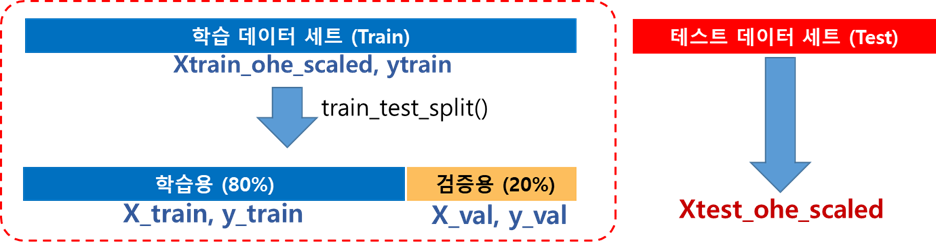

### (1) 훈련 및 검증 데이터 분할

In [ ]:
# 데이터 분할: test_size=0.2, random_state=0



### (2) 평가지표 확인
- 평가지표가 MAE이므로 skleran의 mean_absolute_error() 함수 사용

### (3) 알고리즘별 학습, 예측, 평가

#### 1) Linear Regression

In [ ]:
# Estimator 설정
 lr_reg = LinearRegression()

#학습
 

#예측

#평가
print('Linear Regression 모델의 MAE : ', <blank>)

#### 2) Decision Tree Regressor

In [ ]:
dt_reg = DecisionTreeRegressor()



#### 3) Random Forest Regressor

In [ ]:
rf_reg = RandomForestRegressor(n_jobs=-1)


#### 4) Extra Trees Regressor

In [ ]:
et_reg = ExtraTreesRegressor(n_jobs=-1)


#### 5) XGB Regressor

In [ ]:
xgb_reg = XGBRegressor(n_jobs=-1)


#### 6) LGBM Regressor

In [ ]:
lgb_reg = LGBMRegressor(verbose=-1, n_jobs=-1)


**[정리] 가장 성능이 좋은 모델을 선정** 

In [ ]:
# 상기의 내용을 for문을 이용하여 고쳐보세요
# 1) Linear Regression ~ 6) LGBM Regressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_jobs=-1),
    'Extra Trees Regressor': ExtraTreesRegressor(n_jobs=-1),
    'XGB Regressor' : XGBRegressor(n_jobs=-1),
    'LGBM Regressor' : LGBMRegressor(<blank>, <blank>)
}

# 초기화: selected_estimator, pre_rmsle
selected_estimator = None
min_mae = float('inf')


for name,estimator  in models.items():    
    <blank>.fit(X_train, y_train)   #학습
    pred= <blank>                #예측
    mae_ =  <blank>   #평가
    print(f'[{name} 모델의 mae]: {round(mae_, 3)}')
    #print('{:} 모델의 MAE : {:.3f}'.format(name, mae_))

   # 최고 성능 모델 기록
    if mae_  <blank> min_mae:
        selected_estimator = <blank>
        min_mae = <blank>
        print(f'selected estimator: {name}')
    

### (4) 하이퍼 파라미터 튜닝


##### [주의] 회귀모델에서의 scoring
- GridSearchCV는 score값이 클수록 우수한 파라미터라고 판단함
- 하지만 회귀모델의 Error지표는 score값이 작을수록 우수한 파라미터임
- 따라서 회귀모델에서는 scoring함수를 negative함수로 활용함
    - https://scikit-learn.org/stable/modules/model_evaluation.html

- 튜닝전에, default parameter일때의 성능을 Cross Validation 기반 재검증

In [ ]:
# 1) (Cross Validation이 목적이므로) 파라미터 설정은 하지 않음
parameters ={}

# 2) GridSearchCV 설정: 
grid_reg = GridSearchCV(selected_estimator, 
                           parameters,
                           cv=5,
                           scoring=<blank>)

# 3) GridSearchCV estimator로 학습: 
grid_reg.fit(Xtrain_ohe_scaled, ytrain)

# 4) Score확인
print('최적 하이퍼 파라미터 score: ', -1*grid_reg.best_score_)

- 실제 하이퍼파라미터 튜닝 시작!

In [ ]:
# 1) 파라미터 후보군 설정
# 많은 하이퍼파라미터를 대상으로 진행할 수 있지만, 시간 관계상 일부만 시도
parameters ={'n_estimators' : [100,200,300],         #defalut =100
             'min_samples_split':[2,3,4]}      #defalut = 2

In [ ]:
# 2) GridSearchCV 설정
grid_reg = GridSearchCV(<blank>, 
                        parameters,
                        cv=3,
                        scoring='neg_mean_absolute_error') 

In [ ]:
# 3) GridSearchCV estimator로 학습
grid_reg.fit(<blank>, <blank>)

In [ ]:
# 4) GridSearchCV 결과 확인
print('최적 하이퍼 파라미터 : ', grid_reg.<blank>)

In [ ]:
# 5) GridSearchCV score 확인
print('최적 하이퍼 파라미터 score: ', -1*grid_reg.<blank>)

## [step5] 모델 선택 및 적용
### (1) test data의 예측값 생성 
- 최적 하이퍼 파라미터로 재학습된 결과는 **grid_reg.best_estimator_** 에 저장되어 있음
- **grid_reg.best_estimator_** 로 test data 예측

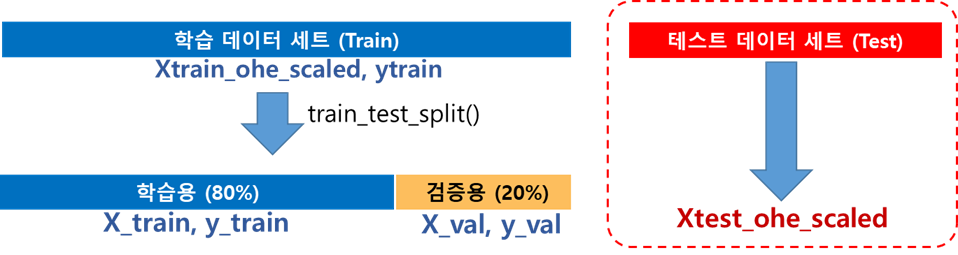

In [ ]:
pred_test = grid_reg.<blank>.predict(<blank>)

### (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)
- 본 프로젝트에서는 target값을 로그 변환하지 않았음
- 따라서 이 과정은 필요없음

### (3) 실제값과 예측값의 분포 비교

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(x=<blank>, ax=<blank>) # 실제값 
sns.histplot(x=<blank>, ax=<blank>)  # 예측값

plt.show()

## [step6] 결과 파일 생성 
### (1) 예시 파일 불러오기 

In [ ]:
#예시 파일 불러와서 dataframe 생성
submission = <blank>('./data/sample_submission.csv')

### (2) 예측 결과 저장

In [ ]:
#test data의 예측 결과 저장하기
submission[<blank>] = <blank>
submission.head(5)

### (3) 제출할 csv파일 생성

In [ ]:
#제출 파일 생성하기
submission.<blank>('./data/MySubmission.csv', index=False)

**수고하셨습니다** 